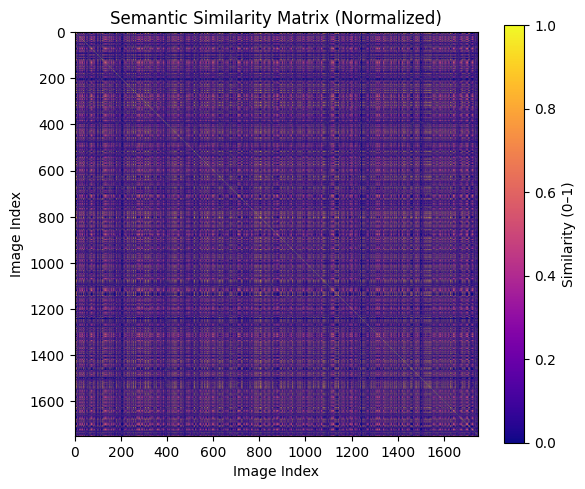

✅ Saved semantic_similarity.npy
Matrix shape: (1750, 1750)
Max value: 10.0
Non-zero pairs: 1065784


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Load labels ---
labels = np.load("../data/kay_labels.npy", allow_pickle=True)

# FIX: transpose
if labels.shape[0] == 4:
    labels = labels.T

labels = labels.astype(str)

def compute_label_similarity(labels, weights=[4, 3, 2, 1]):
    n_images = labels.shape[0]
    sim_matrix = np.zeros((n_images, n_images))
    for i in range(n_images):
        for j in range(n_images):
            score = sum(weights[k] for k in range(4) if labels[i, k] == labels[j, k])
            sim_matrix[i, j] = score
    return sim_matrix

# --- Compute and normalize ---
semantic_sim = compute_label_similarity(labels)
semantic_sim_normalized = semantic_sim / np.max(semantic_sim)

# --- Visualize ---
plt.figure(figsize=(6, 5))
plt.imshow(semantic_sim_normalized, cmap='plasma')
plt.title("Semantic Similarity Matrix (Normalized)")
plt.colorbar(label="Similarity (0–1)")
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.tight_layout()
plt.savefig("../data/semantic_similarity_matrix.png", dpi=300)
plt.show()

# --- Save ---
np.save("../data/semantic_similarity.npy", semantic_sim)
print("✅ Saved semantic_similarity.npy")
print(f"Matrix shape: {semantic_sim.shape}")
print(f"Max value: {semantic_sim.max()}")
print(f"Non-zero pairs: {(semantic_sim > 0).sum()}")